<a href="https://colab.research.google.com/github/Zanz-19/Modulo-6/blob/master/M6_L12/M6_L12_router_demo_JoseRamonSanchezAcosta_JosueAlejandroMurilloOrozco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAE-IA · Módulo 6 · L12 — Router de objetos (demo_project)

**Idea:** YOLOv8 detecta objetos; según la **clase** de cada uno, su recorte se manda a un
**modelo distinto**: seres vivos → BLIP (caption), objetos con texto → OCR (Tesseract), el resto → solo etiqueta.

```
imagen → [validar] → YOLOv8 → detecciones
                          ↓ (por cada detección)
              ¿ser vivo?      → recorte → BLIP-large → caption
              ¿objeto+texto?  → recorte → Tesseract  → texto
              ¿otra clase?    → solo etiqueta
              ¿nada detectado? → caption de la imagen completa (fallback)
```



## 1 — Setup

In [29]:
!apt-get install -y -q tesseract-ocr tesseract-ocr-spa > /dev/null
!pip install -q ultralytics==8.4.170 transformers==5.16.1 accelerate==1.14.0 gradio==6.26.0 pytesseract==0.3.13

In [30]:
import os, sys, time, random
from typing import NamedTuple
import numpy as np
import torch
from PIL import Image, ImageOps, ImageDraw

# --- Drive es OPCIONAL: solo para tus imágenes de prueba. La app no lo necesita. ---
USE_DRIVE  = True
INPUT_DIR  = '/content/inputs'
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        INPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/inputs'
    except Exception as e:
        print(f'Drive no disponible ({e}); se usa {INPUT_DIR}')
os.makedirs(INPUT_DIR, exist_ok=True)

# Los pesos van al disco del runtime (Drive no soporta symlinks -> OSError 95 con HF)
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
os.environ['HF_HOME'] = MODEL_CACHE
os.environ['TORCH_HOME'] = MODEL_CACHE
os.environ['YOLO_CONFIG_DIR'] = MODEL_CACHE     # antes de importar ultralytics

if not torch.cuda.is_available():
    raise RuntimeError('Sin GPU. Entorno de ejecución > Cambiar tipo > T4 GPU')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def vram(tag=''):
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM {used:5.2f} / {total:.1f} GB   {tag}')

import ultralytics, transformers, pytesseract
print(torch.cuda.get_device_name(0)); vram('vacía')
print('Python', sys.version.split()[0], '| torch', torch.__version__)
print('ultralytics', ultralytics.__version__, '| transformers', transformers.__version__)
print('Tesseract', pytesseract.get_tesseract_version(), pytesseract.get_languages())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tesla T4
  VRAM  0.98 / 15.6 GB   vacía
Python 3.13.15 | torch 2.11.0+cu128
ultralytics 8.4.170 | transformers 5.16.1
Tesseract 5.3.4 ['eng', 'osd', 'spa']


## 2 — Etapa 1: validar la entrada y detectar

**`coerce_image`** recibe *lo que sea* que entregue el usuario y devuelve una imagen PIL RGB o un `ValueError` con un mensaje legible.
**`detect`** recibe PIL y devuelve una lista de `Det(label, conf, box)` ordenada de mayor a menor confianza (`box` = esquinas en píxeles `x1,y1,x2,y2`).

Dos detalles que cambié respecto a L11: (1) se restaura la rama `np.ndarray` de `coerce_image` (en el L11 quedó comentada por el experimento 2) y
(2) se aplica `ImageOps.exif_transpose`, porque una foto de celular puede venir rotada solo "por metadato" y YOLO vería la imagen de lado.

In [31]:
MAX_SIDE, MIN_SIDE = 1024, 32

def coerce_image(x):
    """Cualquier cosa -> PIL RGB, o ValueError con un mensaje para el usuario."""
    if x is None:
        raise ValueError('No se recibió ninguna imagen. Sube una.')
    if isinstance(x, np.ndarray):                    # Gradio puede entregar numpy
        try:
            x = Image.fromarray(x.astype(np.uint8))
        except Exception:
            raise ValueError('El arreglo recibido no es una imagen válida.')
    if not isinstance(x, Image.Image):
        raise ValueError('Entrada no soportada. Sube un archivo de imagen (jpg, png, webp).')
    x = ImageOps.exif_transpose(x)                   # respeta la orientación del celular
    x = x.convert('RGB')                             # L, RGBA, P, CMYK -> RGB
    w, h = x.size
    if min(w, h) < MIN_SIDE:
        raise ValueError(f'Imagen demasiado pequeña ({w}x{h}). Mínimo {MIN_SIDE}x{MIN_SIDE}.')
    if max(w, h) > MAX_SIDE:                         # una foto de 12 MP satura la T4
        s = MAX_SIDE / max(w, h)
        x = x.resize((int(w * s), int(h * s)), Image.LANCZOS)
    return x

class Det(NamedTuple):
    label: str
    conf: float
    box: tuple          # (x1, y1, x2, y2) en píxeles

def detect(img, conf=0.25):
    """PIL RGB -> [Det], la más segura primero."""
    # Se pasa el PIL directo: ultralytics lo trata como RGB. Un np.array se interpreta
    # como BGR (convención OpenCV) y cambiaría los colores que ve el modelo.
    res = yolo(img, conf=conf, verbose=False)[0]
    dets = [Det(res.names[int(b.cls)], float(b.conf), tuple(map(int, b.xyxy[0].tolist())))
            for b in res.boxes]
    return sorted(dets, key=lambda d: -d.conf)

In [32]:
from ultralytics import YOLO
yolo = YOLO('yolov8n.pt')           # 6 MB; el más rápido y el menos preciso de la familia
print(f'YOLO cargado: {len(yolo.names)} clases COCO'); vram('tras YOLO')


import urllib.request

SAMPLES_DIR      = os.path.join(INPUT_DIR, 'samples')     # se crea por código
SAMPLES_BASE_URL = 'https://raw.githubusercontent.com/Zanz-19/Modulo-6/master/samples/'
SAMPLE_FILES = ['persona_motosierra.jpg', 'bebe_llorando.jpg', 'perro_arbol.jpg',
                'calle_lluvia.jpg', 'reloj.jpg', 'aspiradora.jpg',
                'pexels_2393767.jpg', 'coche_verde.jpg', 'mujer_conferencia.jpg', 'stop_sign.jpg']
os.makedirs(SAMPLES_DIR, exist_ok=True)

def fetch_samples():
    """Descarga las que falten; si una falla, sigue con las demás."""
    for f in SAMPLE_FILES:
        dst = os.path.join(SAMPLES_DIR, f)
        if os.path.exists(dst):
            continue
        try:
            urllib.request.urlretrieve(SAMPLES_BASE_URL + f, dst)
        except Exception as e:
            print(f'  no se pudo descargar {f}: {e}')

IMG_EXTS = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
def load_inputs(n=10):
    fetch_samples()
    names = [f for f in sorted(os.listdir(SAMPLES_DIR)) if f.lower().endswith(IMG_EXTS)][:n]
    return {f: Image.open(os.path.join(SAMPLES_DIR, f)) for f in names}

samples = load_inputs()
if not samples:                                   # último recurso: imagen de ultralytics
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', '/content/bus.jpg')
    samples = {'bus.jpg': Image.open('/content/bus.jpg')}
print('imágenes de prueba:', list(samples))

if not samples:
    import urllib.request
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', '/content/bus.jpg')
    samples = {'bus.jpg': Image.open('/content/bus.jpg')}
print('imágenes de prueba:', list(samples))

for name, im in samples.items():
    dets = detect(coerce_image(im))
    print(f'{name[:24]:24s} -> ' + (', '.join(f'{d.label} {d.conf:.2f}' for d in dets[:6]) or '*** NADA DETECTADO ***'))

YOLO cargado: 80 clases COCO
  VRAM  0.98 / 15.6 GB   tras YOLO
imágenes de prueba: ['aspiradora.jpg', 'bebe_llorando.jpg', 'calle_lluvia.jpg', 'coche_verde.jpg', 'mujer_conferencia.jpg', 'perro_arbol.jpg', 'persona_motosierra.jpg', 'pexels_2393767.jpg', 'reloj.jpg', 'stop_sign.jpg']
imágenes de prueba: ['aspiradora.jpg', 'bebe_llorando.jpg', 'calle_lluvia.jpg', 'coche_verde.jpg', 'mujer_conferencia.jpg', 'perro_arbol.jpg', 'persona_motosierra.jpg', 'pexels_2393767.jpg', 'reloj.jpg', 'stop_sign.jpg']
aspiradora.jpg           -> toothbrush 0.51, person 0.34
bebe_llorando.jpg        -> person 0.89
calle_lluvia.jpg         -> *** NADA DETECTADO ***
coche_verde.jpg          -> person 0.76, person 0.75, person 0.71, person 0.44, motorcycle 0.39, handbag 0.32
mujer_conferencia.jpg    -> person 0.92, person 0.88, chair 0.82, chair 0.51, person 0.47, chair 0.45
perro_arbol.jpg          -> dog 0.93, sports ball 0.36
persona_motosierra.jpg   -> person 0.57, person 0.53
pexels_2393767.jpg       -

## 3 — Etapa 2: el enrutamiento

Aquí está la idea del proyecto. La decisión **no** se toma sobre la imagen completa sino **por cada detección**, usando su clase:

| Ruta | Clases COCO | Modelo destino |
|---|---|---|
| `caption` | seres vivos (persona, perro, gato, ave, caballo...) | BLIP-large |
| `ocr` | objetos que suelen llevar texto (señal de alto, libro, tv, laptop, celular, botella...) | Tesseract |
| `skip` | todo lo demás | ninguno: solo se muestra la etiqueta |

Por qué es una **heurística** y no una verdad: YOLO-COCO no tiene una clase "texto". Que un `book` lleve texto legible es probable, no seguro;
por eso el OCR puede devolver vacío y eso tiene que ser una respuesta válida (se maneja en el paso 4).

Casos que `plan()` ya resuelve: **nada detectado** (fallback: caption de la imagen completa), **recortes diminutos** (se omiten, el OCR y BLIP no sirven con 10 px),
y **demasiados objetos** (se limita a los más seguros para no disparar el tiempo de GPU).

In [33]:
LIVING = {'person', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe'}
TEXTY  = {'stop sign', 'book', 'tv', 'laptop', 'cell phone', 'bottle', 'parking meter'}
ROUTES = {**{c: 'caption' for c in LIVING}, **{c: 'ocr' for c in TEXTY}}

# Un typo en una clase ('cellphone') nunca fallaría: simplemente nunca enrutaría. Se verifica al cargar.
_bad = sorted(c for c in ROUTES if c not in set(yolo.names.values()))
assert not _bad, f'Clases que no existen en COCO: {_bad}'

MAX_OBJECTS = 6      # máximo de detecciones que se procesan por imagen
MIN_CROP    = 24     # px; debajo de esto el recorte no sirve para BLIP ni para OCR
PAD_FRAC    = 0.08   # margen alrededor de la caja (proporcional a su tamaño)

class Task(NamedTuple):
    label: str
    conf: float
    box: tuple
    route: str          # 'caption' | 'ocr' | 'skip'
    crop: Image.Image
    note: str

def crop_box(img, box, pad_frac=PAD_FRAC):
    """Recorta con margen; el margen se recorta a los límites de la imagen."""
    x1, y1, x2, y2 = box
    pad = int(pad_frac * max(x2 - x1, y2 - y1))
    w, h = img.size
    return img.crop((max(0, x1 - pad), max(0, y1 - pad), min(w, x2 + pad), min(h, y2 + pad)))

def _inter_frac(a, b):
    """Fracción del área de la caja a que cae dentro de la caja b."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area  = (a[2] - a[0]) * (a[3] - a[1])
    return inter / area if area else 0.0

def drop_nested(dets, thr=0.85):
    """Quita una detección si otra de la MISMA clase y más segura la contiene casi por completo."""
    kept = []
    for d in dets:                       # ya vienen ordenadas de mayor a menor confianza
        if any(k.label == d.label and _inter_frac(d.box, k.box) >= thr for k in kept):
            continue
        kept.append(d)
    return kept

def plan(img, dets, max_objects=MAX_OBJECTS):
    """(PIL, [Det]) -> [Task]. No ejecuta ningún modelo: solo decide a dónde va cada recorte."""
    dets = drop_nested(dets)

    w, h = img.size
    if not dets:
        # Encontrar nada es una ENTRADA VÁLIDA (COCO solo tiene 80 clases), no un error.
        return [Task('(imagen completa)', 0.0, (0, 0, w, h), 'caption', img,
                     'YOLO no encontró objetos: se describe la imagen completa')]
    tasks = []
    for d in dets[:max_objects]:
        crop  = crop_box(img, d.box)
        route = ROUTES.get(d.label, 'skip')
        note  = '' if route != 'skip' else 'sin ruta para esta clase'
        if crop.width < MIN_CROP or crop.height < MIN_CROP:
            route, note = 'skip', f'recorte demasiado pequeño ({crop.width}x{crop.height})'
        tasks.append(Task(d.label, d.conf, d.box, route, crop, note))
    return tasks

ROUTE_COLOR = {'caption': '#22aa55', 'ocr': '#2266dd', 'skip': '#999999'}

def draw_tasks(img, tasks):
    """Devuelve una copia con cada caja coloreada según su ruta."""
    out = img.copy(); dr = ImageDraw.Draw(out)
    for t in tasks:
        if t.label == '(imagen completa)':
            continue
        dr.rectangle(t.box, outline=ROUTE_COLOR[t.route], width=3)
        dr.text((t.box[0] + 4, t.box[1] + 2), f'{t.label} {t.conf:.2f} -> {t.route}', fill=ROUTE_COLOR[t.route])
    return out

--- entradas reales ---
aspiradora.jpg
  toothbrush         0.51  ruta=skip     recorte=(457, 711)  sin ruta para esta clase
  person             0.34  ruta=caption  recorte=(424, 343)  


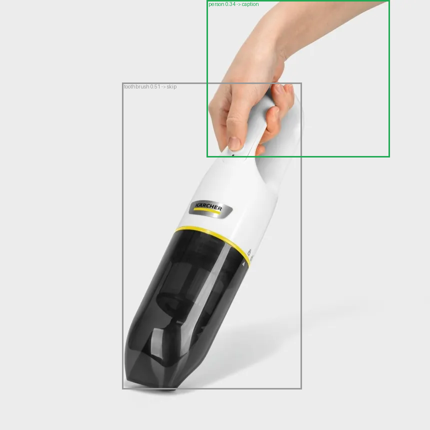

bebe_llorando.jpg
  person             0.89  ruta=caption  recorte=(731, 740)  


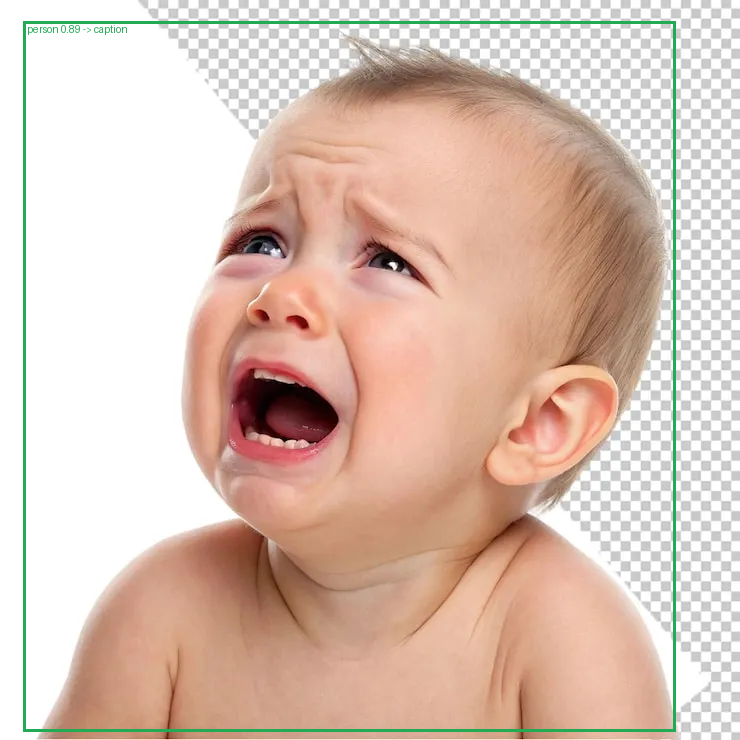

calle_lluvia.jpg
  (imagen completa)  0.00  ruta=caption  recorte=(500, 667)  YOLO no encontró objetos: se describe la imagen completa


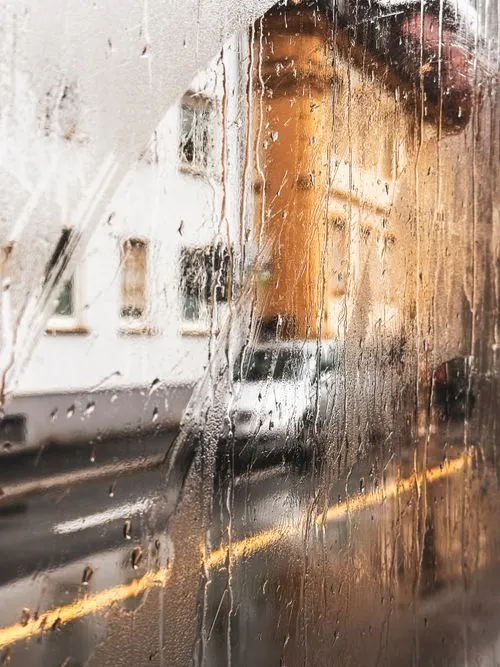

coche_verde.jpg
  person             0.76  ruta=caption  recorte=(167, 587)  
  person             0.75  ruta=caption  recorte=(89, 152)  
  person             0.71  ruta=caption  recorte=(125, 203)  
  person             0.44  ruta=caption  recorte=(158, 305)  
  motorcycle         0.39  ruta=skip     recorte=(930, 657)  sin ruta para esta clase
  handbag            0.32  ruta=skip     recorte=(102, 191)  sin ruta para esta clase


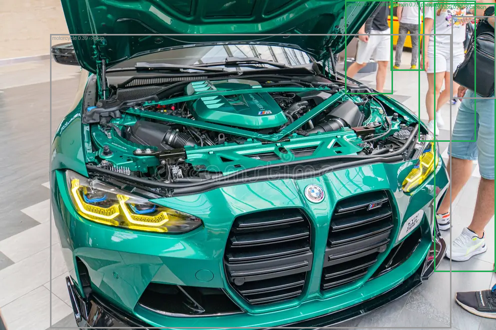

mujer_conferencia.jpg
  person             0.92  ruta=caption  recorte=(155, 237)  
  person             0.88  ruta=caption  recorte=(162, 165)  
  chair              0.82  ruta=skip     recorte=(87, 89)  sin ruta para esta clase
  chair              0.51  ruta=skip     recorte=(69, 66)  sin ruta para esta clase
  person             0.47  ruta=caption  recorte=(66, 104)  
  chair              0.45  ruta=skip     recorte=(68, 51)  sin ruta para esta clase


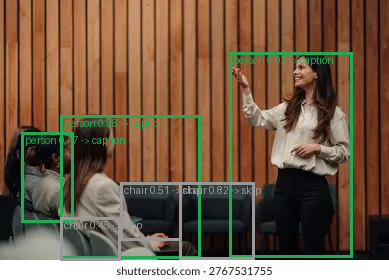

perro_arbol.jpg
  dog                0.93  ruta=caption  recorte=(290, 330)  
  sports ball        0.36  ruta=skip     recorte=(30, 21)  recorte demasiado pequeño (30x21)


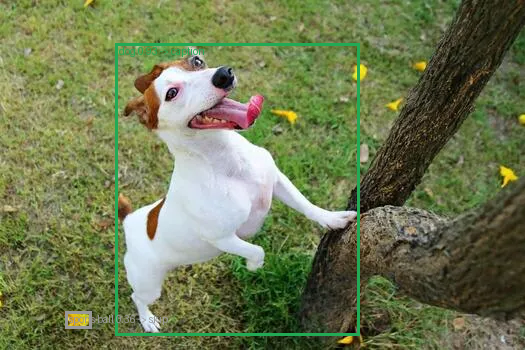

persona_motosierra.jpg
  person             0.57  ruta=caption  recorte=(330, 300)  


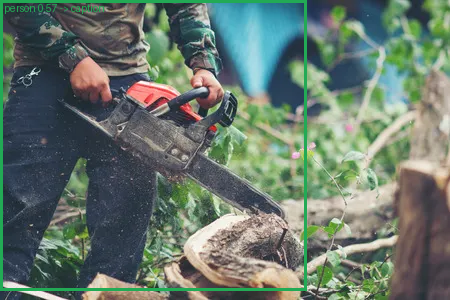

pexels_2393767.jpg
  bird               0.91  ruta=caption  recorte=(137, 169)  


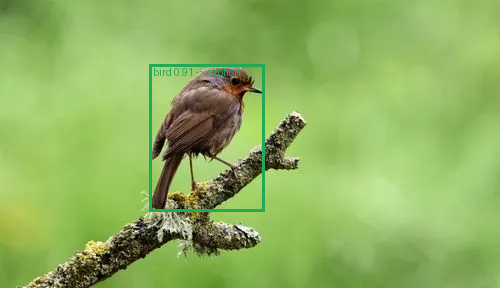

reloj.jpg
  clock              0.91  ruta=skip     recorte=(144, 147)  sin ruta para esta clase


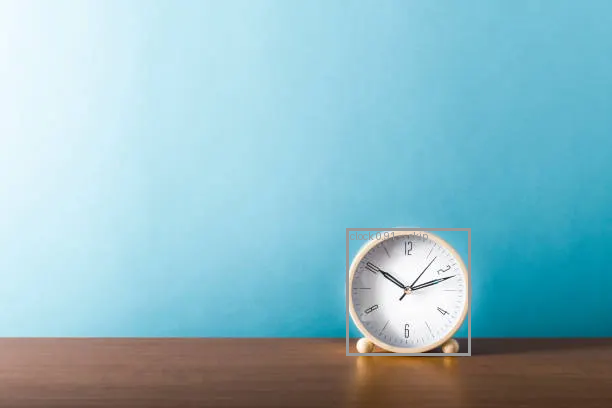

stop_sign.jpg
  stop sign          0.94  ruta=ocr      recorte=(332, 422)  


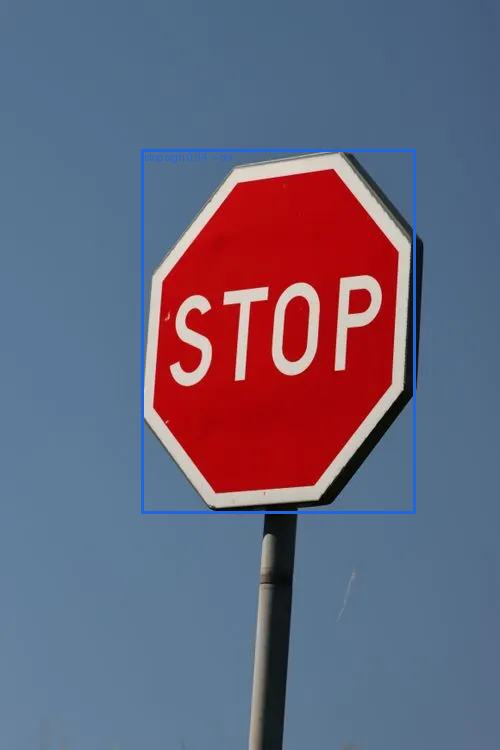


--- entradas hostiles: ninguna debe levantar traceback ---
  None           -> ValueError (mensaje al usuario): No se recibió ninguna imagen. Sube una.
  numpy 64x64    -> ok, 1 tarea(s): (imagen completa)->caption
  numpy 1D       -> ValueError (mensaje al usuario): Imagen demasiado pequeña (1x10). Mínimo 32x32.
  texto          -> ValueError (mensaje al usuario): Entrada no soportada. Sube un archivo de imagen (jpg, png, webp).
  1x1            -> ValueError (mensaje al usuario): Imagen demasiado pequeña (1x1). Mínimo 32x32.
  gris           -> ok, 1 tarea(s): person->caption
  RGBA           -> ok, 2 tarea(s): toothbrush->skip, person->caption
  12 MP blanca   -> ok, 1 tarea(s): (imagen completa)->caption


In [34]:
from IPython.display import display

def show_plan(img_raw, conf=0.25):
    img = coerce_image(img_raw)
    tasks = plan(img, detect(img, conf))
    for t in tasks:
        print(f'  {t.label:18s} {t.conf:.2f}  ruta={t.route:8s} recorte={t.crop.size}  {t.note}')
    display(draw_tasks(img, tasks).resize((img.width // 2, img.height // 2)) if img.width > 800 else draw_tasks(img, tasks))
    return tasks

print('--- entradas reales ---')
for name, im in samples.items():
    print(name); show_plan(im)

print('\n--- entradas hostiles: ninguna debe levantar traceback ---')
ref = next(iter(samples.values()))
hostile = [('None', None), ('numpy 64x64', np.zeros((64, 64, 3), dtype=np.uint8)),
           ('numpy 1D', np.zeros(10)), ('texto', 'hola'), ('1x1', Image.new('RGB', (1, 1))),
           ('gris', ref.convert('L')), ('RGBA', ref.convert('RGBA')),
           ('12 MP blanca', Image.new('RGB', (4000, 3000), 'white'))]
for tag, bad in hostile:
    try:
        img = coerce_image(bad)
        ts = plan(img, detect(img))
        print(f'  {tag:14s} -> ok, {len(ts)} tarea(s): ' + ', '.join(f'{t.label}->{t.route}' for t in ts))
    except ValueError as e:
        print(f'  {tag:14s} -> ValueError (mensaje al usuario): {e}')

**Cargar BLIP-large**

In [35]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import re

BLIP_ID    = 'Salesforce/blip-image-captioning-large'
blip_proc  = BlipProcessor.from_pretrained(BLIP_ID)
blip_model = BlipForConditionalGeneration.from_pretrained(
    BLIP_ID, dtype=torch.float16).to('cuda').eval()
vram('tras BLIP')

def clean_caption(s):
    s = re.sub(r"\s+'\s*(s|t|re|ve|ll|d|m)\b", r"'\1", s.strip())   # "it ' s" -> "it's"
    s = re.sub(r'^there (is|are) ', '', s, flags=re.I)                # quita "there is/are"
    return s[:1].upper() + s[1:]

def caption_crop(img, max_new_tokens=40):
    """PIL RGB -> str. float16 a la entrada, igual que como se cargó el modelo."""
    inp = blip_proc(images=img, return_tensors='pt').to('cuda', torch.float16)
    with torch.no_grad():
        out = blip_model.generate(**inp, max_new_tokens=max_new_tokens, num_beams=3)
    return clean_caption(blip_proc.decode(out[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

  VRAM  0.99 / 15.6 GB   tras BLIP


**OCR sobre recortes**

In [36]:
import cv2, pytesseract

OCR_LANG, OCR_TARGET_H, MAX_INK_FRAC = 'eng+spa', 400, 0.15

def _accept(w, c):
    """Palabra confiable: >=3 caracteres con conf>=70, o cualquier longitud con conf>=85."""
    n = sum(ch.isalnum() for ch in w)
    return n > 0 and ((n >= 3 and c >= 70) or c >= 85)

def _ocr_pass(arr):
    d = pytesseract.image_to_data(arr, lang=OCR_LANG, config='--psm 11 --oem 3',
                                  output_type=pytesseract.Output.DICT)
    out = []
    for w, c in zip(d['text'], d['conf']):
        w = w.strip()
        if w and _accept(w, float(c)):
            out.append((w, float(c)))
    return out

def _sin_gigantes(chan):
    """Binariza (Otsu) y borra las manchas enormes (aro, poste, fondo). Tinta negra sobre blanco."""
    _, bw = cv2.threshold(chan, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    outs = []
    for fg in (bw, 255 - bw):                      # probar ambas polaridades
        n, lab, st, _ = cv2.connectedComponentsWithStats(fg, connectivity=8)
        keep = np.zeros_like(fg)
        for i in range(1, n):
            if st[i, cv2.CC_STAT_AREA] <= MAX_INK_FRAC * fg.size:
                keep[lab == i] = 255
        outs.append(255 - keep)
    return outs

def ocr_variants(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    v = {'gris': gray, 'gris inv': 255 - gray}
    for ch_name, ch in (('gris', gray), ('min(RGB)', rgb.min(axis=2))):
        for k, a in enumerate(_sin_gigantes(ch)):
            v[f'{ch_name} bin{k}'] = a
    return v

def ocr_crop(img):
    """PIL RGB -> (texto, confianza media, variante ganadora). ('', 0.0, '') = no hay texto legible."""
    rgb = np.array(img.convert('RGB'))
    if rgb.shape[0] < OCR_TARGET_H:                # recortes chicos: subir resolución
        f = OCR_TARGET_H / rgb.shape[0]
        rgb = cv2.resize(rgb, None, fx=f, fy=f, interpolation=cv2.INTER_CUBIC)
    best, best_name = [], ''
    for name, arr in ocr_variants(rgb).items():
        words = _ocr_pass(arr)
        if sum(c for _, c in words) > sum(c for _, c in best):
            best, best_name = words, name
    if not best:
        return '', 0.0, ''
    return ' '.join(w for w, _ in best), sum(c for _, c in best) / len(best), best_name

In [37]:
class Result(NamedTuple):
    task: Task
    output: str      # caption, texto OCR, o '' si la ruta fue skip
    info: str        # tiempo, confianza o motivo

def run_tasks(tasks):
    """[Task] -> [Result]. Un recorte que falle no tumba a los demás."""
    results = []
    for t in tasks:
        t0 = time.time()
        try:
            if t.route == 'caption':
                out, info = caption_crop(t.crop), f'BLIP {time.time()-t0:.2f}s'
            elif t.route == 'ocr':
                text, conf, var = ocr_crop(t.crop)
                out  = text if text else '(sin texto legible)'
                info = f'OCR conf {conf:.0f} [{var}], {time.time()-t0:.2f}s' if text else 'OCR sin texto confiable'
            else:
                out, info = '', t.note
        except Exception as e:
            print(f'  [fallo en {t.label}] {type(e).__name__}: {e}')
            out, info = '(error al procesar este objeto)', 'falló'
        results.append(Result(t, out, info))
    return results

def run_pipeline(x, conf=0.25):
    img = coerce_image(x)
    tasks = plan(img, detect(img, conf))
    return img, tasks, run_tasks(tasks)

# --- 1) OCR sin foto real: recortes sintéticos que entran por la ruta 'ocr' ---
def _texto(txt, fg, bg, size, fs):
    im = Image.new('RGB', size, bg)
    ImageDraw.Draw(im).text((6, 2), txt, fill=fg, font=ImageFont.load_default(size=fs))
    return im

from PIL import ImageFont
fake = [Task('stop sign', .9, (0, 0, 260, 130), 'ocr', _texto('STOP', 'white', (200, 20, 20), (260, 130), 70), ''),
        Task('book', .8, (0, 0, 120, 40), 'ocr', _texto('Leche', 'black', 'white', (120, 40), 26), ''),
        Task('bottle', .7, (0, 0, 200, 200), 'ocr', Image.new('RGB', (200, 200), (120, 160, 90)), '')]
print('--- OCR sintético ---')
for r in run_tasks(fake):
    print(f'  {r.task.label:10s} -> {r.output!r:26s} ({r.info})')

# --- 2) Pipeline completo sobre tus imágenes ---
print('\n--- pipeline completo ---')
for name, im in samples.items():
    img, tasks, results = run_pipeline(im)
    print(name)
    for r in results:
        print(f'  [{r.task.route:7s}] {r.task.label:18s} {r.task.conf:.2f} -> {r.output or "-":60.60s} | {r.info}')
vram('fin')

--- OCR sintético ---
  stop sign  -> 'STOP'                     (OCR conf 95 [gris], 1.29s)
  book       -> 'Leche'                    (OCR conf 96 [gris], 1.36s)
  bottle     -> '(sin texto legible)'      (OCR sin texto confiable)

--- pipeline completo ---
aspiradora.jpg
  [skip   ] toothbrush         0.51 -> -                                                            | sin ruta para esta clase
  [caption] person             0.34 -> A person that is holding a remote control in their hand      | BLIP 0.99s
bebe_llorando.jpg
  [caption] person             0.89 -> A baby that is crying with a toothbrush in it's mouth        | BLIP 1.17s
calle_lluvia.jpg
  [caption] (imagen completa)  0.00 -> A view of a street through a window with rain on it          | BLIP 1.08s
coche_verde.jpg
  [caption] person             0.76 -> A man standing next to a green car with a hood up            | BLIP 0.67s
  [caption] person             0.75 -> A woman walking down the street with a cell phone in her

**El guardrail**

In [38]:
class EntradaInvalida(ValueError):
    """Error causado por la entrada del usuario; su mensaje ya está escrito para mostrarse."""

GPS_IFD = 0x8825

def privacy_report(x):
    """Mira la imagen ORIGINAL (antes de limpiarla). -> {'gps': bool, 'n_tags': int}"""
    if not isinstance(x, Image.Image):
        return {'gps': False, 'n_tags': 0}
    try:
        exif = x.getexif()
        return {'gps': bool(exif.get_ifd(GPS_IFD)), 'n_tags': len(exif)}
    except Exception:          # un EXIF corrupto no debe tumbar la app
        return {'gps': False, 'n_tags': 0}

def strip_metadata(img):
    """GUARDRAIL. Reconstruye la imagen desde sus píxeles: sin EXIF, sin GPS, sin XMP."""
    return Image.fromarray(np.array(img.convert('RGB')))

def coerce_image(x):
    """Cualquier cosa -> PIL RGB sin metadata, o EntradaInvalida con un mensaje para el usuario."""
    if x is None:
        raise EntradaInvalida('No se recibió ninguna imagen. Sube una.')
    if isinstance(x, np.ndarray):
        if x.ndim not in (2, 3) or (x.ndim == 3 and x.shape[2] not in (3, 4)):
            raise EntradaInvalida('El arreglo recibido no es una imagen válida.')
        x = Image.fromarray(x.astype(np.uint8))
    if not isinstance(x, Image.Image):
        raise EntradaInvalida('Entrada no soportada. Sube un archivo de imagen (jpg, png, webp).')
    x = ImageOps.exif_transpose(x)                   # primero la orientación, que vive en el EXIF
    x = x.convert('RGB')
    w, h = x.size
    if min(w, h) < MIN_SIDE:
        raise EntradaInvalida(f'Imagen demasiado pequeña ({w}x{h}). Mínimo {MIN_SIDE}x{MIN_SIDE}.')
    if max(w, h) > MAX_SIDE:
        s = MAX_SIDE / max(w, h)
        x = x.resize((int(w * s), int(h * s)), Image.LANCZOS)
    return strip_metadata(x)                         # lo último: nada de lo anterior deja rastro

**analyse(), la puerta de entrada**


In [39]:
import traceback, io

AI_NOTE = 'Las descripciones las genera un modelo de IA (BLIP) y pueden inventar detalles.'

class Outcome(NamedTuple):
    image: object      # PIL con las cajas dibujadas; None si hubo error
    rows: list         # [[objeto, confianza, ruta, resultado, detalle], ...]
    notes: list        # avisos para el usuario
    error: str         # '' si todo salió bien

def analyse(x, conf=0.25):
    """Única puerta de entrada de la app. Nunca lanza excepción: siempre devuelve un Outcome."""
    try:
        try:
            conf = float(conf)
        except (TypeError, ValueError):
            raise EntradaInvalida('La confianza mínima no es un número válido.')
        if not 0.05 <= conf <= 0.95:
            raise EntradaInvalida('La confianza mínima debe estar entre 0.05 y 0.95.')
        priv = privacy_report(x)                 # se mira el ORIGINAL, antes de limpiarlo
        img  = coerce_image(x)                   # valida y quita toda la metadata
        dets = detect(img, conf)
        omitidos = max(0, len(drop_nested(dets)) - MAX_OBJECTS)
        tasks   = plan(img, dets)
        results = run_tasks(tasks)

        notes = []
        if priv['gps']:
            notes.append('Tu foto traía ubicación GPS: se eliminó antes de procesarla.')
        elif priv['n_tags']:
            notes.append(f"Se eliminaron {priv['n_tags']} etiquetas de metadatos (EXIF) de tu foto.")
        if tasks[0].label == '(imagen completa)':
            notes.append(tasks[0].note + '.')
        if omitidos:
            notes.append(f'Se omitieron {omitidos} objeto(s) de menor confianza (máximo {MAX_OBJECTS}).')
        notes.append(AI_NOTE)

        rows = [[r.task.label, f'{r.task.conf:.2f}', r.task.route, r.output or '—', r.info]
                for r in results]
        return Outcome(draw_tasks(img, tasks), rows, notes, '')

    except EntradaInvalida as e:                 # culpa de la entrada: el mensaje es para el usuario
        return Outcome(None, [], [], str(e))
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        return Outcome(None, [], [], 'La GPU se quedó sin memoria. Prueba con una imagen más pequeña.')
    except Exception:                            # culpa del código: detalle al log, mensaje genérico
        traceback.print_exc()
        return Outcome(None, [], [], 'Ocurrió un error interno. Prueba con otra imagen.')

**Celda de prueba**

In [40]:
print('--- guardrail: foto con GPS ---')
exif = Image.Exif()
gps = exif.get_ifd(GPS_IFD)
gps[1], gps[2], gps[3], gps[4] = 'N', (19., 25., 48.), 'W', (99., 7., 59.)
buf = io.BytesIO()
next(iter(samples.values())).convert('RGB').save(buf, 'JPEG', exif=exif); buf.seek(0)
con_gps = Image.open(buf)
print('original          :', privacy_report(con_gps))
print('solo convert(RGB) : exif sigue en .info ->', 'exif' in con_gps.convert('RGB').info)
limpia = coerce_image(con_gps)
print('tras coerce_image :', privacy_report(limpia), '| exif en .info ->', 'exif' in limpia.info)

print('\n--- analyse() ---')
casos = [('GPS', con_gps), ('None', None), ('texto', 'hola'), ('1x1', Image.new('RGB', (1, 1))),
         ('numpy 1D', np.zeros(10)), ('blanca', Image.new('RGB', (600, 400), 'white'))]
casos += [(n, im) for n, im in samples.items() if n in ('coche_verde.jpg', 'stop_sign.jpg')]
for tag, x in casos:
    o = analyse(x)
    print(f'{tag:16s} error={o.error!r}  filas={len(o.rows)}\\n{"":16s} avisos={o.notes}')
print('conf=5   ->', analyse(samples["stop_sign.jpg"], conf=5).error)

--- guardrail: foto con GPS ---
original          : {'gps': True, 'n_tags': 1}
solo convert(RGB) : exif sigue en .info -> True
tras coerce_image : {'gps': False, 'n_tags': 0} | exif en .info -> False

--- analyse() ---
GPS              error=''  filas=2\n                 avisos=['Tu foto traía ubicación GPS: se eliminó antes de procesarla.', 'Las descripciones las genera un modelo de IA (BLIP) y pueden inventar detalles.']
None             error='No se recibió ninguna imagen. Sube una.'  filas=0\n                 avisos=[]
texto            error='Entrada no soportada. Sube un archivo de imagen (jpg, png, webp).'  filas=0\n                 avisos=[]
1x1              error='Imagen demasiado pequeña (1x1). Mínimo 32x32.'  filas=0\n                 avisos=[]
numpy 1D         error='El arreglo recibido no es una imagen válida.'  filas=0\n                 avisos=[]
blanca           error=''  filas=1\n                 avisos=['YOLO no encontró objetos: se describe la imagen completa.', 'Las d

In [46]:
import gradio as gr
import pandas as pd

def gradio_interface(image_input, conf_slider):
    outcome = analyse(image_input, conf=conf_slider)

    if outcome.error:
        error_md = f"### ❌ Error en la Entrada\n**{outcome.error}**"
        return None, pd.DataFrame(), error_md

    columns = ["Objeto", "Confianza", "Ruta", "Resultado", "Detalle / Tiempo"]
    df = pd.DataFrame(outcome.rows, columns=columns) if outcome.rows else pd.DataFrame(columns=columns)

    notes_md = "### ℹ️ Avisos del Pipeline\n" + "\n".join(f"- {note}" for note in outcome.notes)

    return outcome.image, df, notes_md

with gr.Blocks(title="Router de Objetos Multimodal") as demo:
    gr.Markdown(
        """
        # 🤖 Router de Objetos Multimodal (YOLOv8 + BLIP + OCR)
        Esta aplicación analiza imágenes y aplica un **enrutamiento dinámico** según la clase detectada por YOLO:
        - **Seres vivos (`LIVING`):** Descripciones con **BLIP-large**.
        - **Objetos con texto (`TEXTY`):** Extracción con **Tesseract OCR**.
        - **Otras clases:** Clasificación directa.
        - **Fallback:** Si no hay detecciones, describe la imagen completa.
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(type="pil", label="Imagen de Entrada (JPG, PNG, WEBP)")
            conf_slider = gr.Slider(minimum=0.05, maximum=0.95, value=0.25, step=0.05,
                                    label="Confianza Mínima YOLO (conf)")
            btn_run = gr.Button("🚀 Procesar Imagen", variant="primary")

        with gr.Column(scale=1):
            output_image = gr.Image(type="pil", label="Detecciones Enrutadas")
            output_notes = gr.Markdown(label="Estado / Avisos")

    with gr.Row():
        output_table = gr.Dataframe(label="Resultados por Objeto", interactive=False, wrap=True)

    btn_run.click(
        fn=gradio_interface,
        inputs=[input_image, conf_slider],
        outputs=[output_image, output_table, output_notes]
    )

gr.close_all()
demo.queue().launch(theme=gr.themes.Soft(), share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8b5e40749dc2e82ab0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [47]:
demo.close() #Descomentar para detener la demo
print('Demo detenida.')

Closing server running on port: 7860
Demo detenida.


**Celda de limpieza de Drive**

In [48]:
import os, shutil
from google.colab import drive
drive.mount('/content/drive')          # no hace nada si ya está montado

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
MODELS_DIR = os.path.join(DRIVE_ROOT, 'models')

CONFIRM = False    # <- léete la tabla de tamaños, cámbialo a True y vuelve a ejecutar


def dir_size(path):
    """Tamaño total en bytes de un archivo o carpeta."""
    if os.path.isfile(path):
        return os.path.getsize(path)
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            try:
                total += os.path.getsize(os.path.join(root, f))
            except OSError:
                pass
    return total


def fmt(n):
    return f'{n/1e9:6.2f} GB' if n >= 1e9 else f'{n/1e6:6.1f} MB'


def limpiar_drive(confirm=False):
    # Seguro: solo se permite borrar exactamente TAE_IA_M6/models
    assert os.path.dirname(MODELS_DIR) == DRIVE_ROOT and os.path.basename(MODELS_DIR) == 'models'
    assert not os.path.islink(MODELS_DIR), 'models/ es un enlace simbólico; no se toca.'

    if not os.path.isdir(MODELS_DIR):
        print(f'No existe {MODELS_DIR}. No hay nada que limpiar.')
        return

    # 1) Imprime cada entrada con su tamaño
    print(f'Contenido de {MODELS_DIR}:')
    total = 0
    for name in sorted(os.listdir(MODELS_DIR)):
        s = dir_size(os.path.join(MODELS_DIR, name))
        total += s
        print(f'  {fmt(s)}  {name}')
    print(f'  {"-"*10}\n  {fmt(total)}  TOTAL a liberar\n')

    # Lo que debe sobrevivir: todo lo demás dentro de TAE_IA_M6 (inputs/, L*_output/, etc.)
    conservar = sorted(e for e in os.listdir(DRIVE_ROOT) if e != 'models')
    print('Se conservará:', conservar or '(nada más en la carpeta)')

    if not confirm:
        print('\nNo se borró nada. Pon CONFIRM = True y vuelve a ejecutar la celda.')
        return

    # 2) Borra solo models/
    shutil.rmtree(MODELS_DIR)

    # 3) Verifica que todo lo demás sigue ahí
    faltan = [e for e in conservar if not os.path.exists(os.path.join(DRIVE_ROOT, e))]
    assert not os.path.exists(MODELS_DIR), 'models/ sigue existiendo'
    assert not faltan, f'¡Faltan entradas que debían sobrevivir!: {faltan}'
    print(f'\nBorrado models/ ({fmt(total)}). Sobrevivieron: {conservar}')


limpiar_drive(CONFIRM)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contenido de /content/drive/MyDrive/TAE_IA_M6/models:
     0.0 MB  .agent_harnesses.json
   10.99 GB  hub
     0.5 MB  xet
  ----------
   10.99 GB  TOTAL a liberar

Se conservará: ['ESC-50', 'ESC50_best.pth', 'ESC50_phase1.pth', 'ESC50_specs', 'L01_output', 'L02_output', 'L03_output', 'L04_output', 'L05_output', 'L06_output', 'L07_output', 'L08_output', 'L09_output', 'L10_output', 'L11_output', 'L12_output', 'L13_output', 'L14_output', 'L15_output', 'L16_output', 'L17_output', 'L18_output', 'L19_output', 'L20_output', 'L21_output', 'L22_output', 'L23_output', 'L24_output', 'L25_output', 'L26_output', 'L27_output', 'L28_output', 'L29_output', 'L30_output', 'datasets', 'env_setup.txt', 'inputs']

No se borró nada. Pon CONFIRM = True y vuelve a ejecutar la celda.


### Preguntas del instructor

**1. ¿Qué recibe y qué devuelve cada etapa?**

| Etapa | Recibe | Devuelve |
|---|---|---|
| `privacy_report` | imagen original (sin limpiar) | `{'gps': bool, 'n_tags': int}` |
| `coerce_image` | cualquier cosa (`None`, numpy, str, PIL...) | PIL RGB sin metadata, o `EntradaInvalida` (subclase de `ValueError`) |
| `detect` | PIL RGB + `conf` | `[Det(label, conf, box)]`, de mayor a menor confianza |
| `plan` | `(PIL, [Det])` | `[Task]` con la ruta decidida (`caption`/`ocr`/`skip`) y el recorte listo. No ejecuta ningún modelo |
| `run_tasks` | `[Task]` | `[Result(task, output, info)]` |
| `analyse` | imagen + `conf` | `Outcome(image, rows, notes, error)`. Nunca lanza excepción |

Los dos modelos están encadenados: la salida de YOLO (clase + recorte) decide qué modelo corre después (BLIP o Tesseract).

**2. ¿Por qué este orden? ¿Qué se rompe si los cambio?**
- **Validar antes de detectar:** si YOLO recibe `None`, un texto o una imagen de 1x1, truena o manda basura a la GPU. Una foto de 12 MP sin reducir satura la T4.
- **Detectar antes de enrutar:** la ruta depende de la clase de cada objeto; sin detección no hay nada que enrutar.
- **Enrutar antes de los modelos destino:** así solo corre BLIP en seres vivos y OCR en objetos con texto. Si corriera todo sobre todo, gastaría GPU en balde y el OCR devolvería basura en un perro.
- **`privacy_report` antes de `coerce_image`:** limpiar borra el EXIF, y después ya no se podría avisar al usuario que traía GPS.
- **`exif_transpose` antes de `strip_metadata`:** la orientación vive en el EXIF. Si borro la metadata primero, una foto de celular queda de lado y YOLO la ve rotada.

**3. ¿Qué pasa si el modelo no encuentra nada?**
- **YOLO sin detecciones:** no es un error, porque COCO solo tiene 80 clases. `plan` devuelve una sola tarea `caption` sobre la imagen completa, con una nota que se muestra al usuario.
- **OCR sin texto confiable:** devuelve `(sin texto legible)`, que es una respuesta válida porque "objeto con texto" es una heurística, no una certeza.
- **Recortes de menos de 24 px:** se marcan como `skip`, porque BLIP y OCR no sirven con ese tamaño.

**4. ¿Dónde se maneja la entrada inválida?**
- **`coerce_image`:** lanza `EntradaInvalida` con mensajes pensados para el usuario (`None`, arreglo numpy inválido, tipo no soportado, imagen menor a 32 px).
- **`analyse`:** valida que `conf` esté entre 0.05 y 0.95 y es la única puerta de entrada, con tres `except`:
  - `EntradaInvalida`: el mensaje va al usuario.
  - `OutOfMemoryError`: libera caché y avisa que use una imagen más pequeña.
  - `Exception`: el traceback va al log y el usuario ve un mensaje genérico.
- **`run_tasks`:** un `try/except` por objeto, así que un recorte que falle no tumba a los demás.
- **`gradio_interface`:** si `outcome.error` viene lleno, muestra un aviso ❌ en lugar de un traceback.
- **Pruebas:** las celdas de entradas hostiles (`None`, numpy 1D, 1x1, texto, RGBA, 12 MP) comprueban que ninguna levante traceback.

**5. ¿Qué cambié respecto a L11 y por qué?**
- **Router por clase:** en L11 la clase solo elegía un *prompt* de estilo. Ahora elige un *modelo distinto* (BLIP o Tesseract), que es enrutamiento condicional real.
- **Decisión por objeto:** antes solo se trataba el objeto principal. Ahora cada detección se recorta y se procesa.
- **Tipos con nombre:** `Det`, `Task`, `Result` y `Outcome` hacen explícito qué viaja entre etapas.
- **`exif_transpose`:** una foto de celular puede venir rotada solo por metadato.
- **YOLO recibe PIL:** un `np.array` se interpretaría como BGR y cambiaría los colores que ve el modelo.
- **Control de carga:** `drop_nested` quita duplicados, `MAX_OBJECTS=6` limita el tiempo de GPU y `MIN_CROP` omite recortes inútiles.
- **Guardrail y avisos:** EXIF/GPS y etiqueta de origen IA (detalle abajo).

### Ética: un guardrail que existe en el código

- **Misuso concreto:** alguien sube una foto de su celular con GPS embebido y comparte el enlace público (`share=True`). La demo puede terminar exponiendo la ubicación de su casa, y el perjudicado es quien tomó la foto sin saberlo.
- **Guardrail:** `strip_metadata()` (se llama dentro de `coerce_image`) reconstruye la imagen desde sus píxeles, sin EXIF, GPS ni XMP. `privacy_report()` le avisa al usuario qué se eliminó. Además, `AI_NOTE` etiqueta que las descripciones las genera un modelo y pueden inventar detalles.
- **Qué NO cubre:**
  - Lo que se ve en la imagen (letreros, fachadas, caras, placas). El OCR incluso podría leerlos.
  - La copia original: Gradio puede guardar el archivo subido en su carpeta temporal antes de que mi código lo limpie.
  - Los errores de BLIP. La etiqueta de IA avisa, pero no evita que invente detalles.

In [44]:
from importlib.metadata import version
for p in ['ultralytics', 'transformers', 'accelerate', 'gradio', 'pytesseract']:
    print(f'{p}=={version(p)}')

ultralytics==8.4.170
transformers==5.16.1
accelerate==1.14.0
gradio==6.26.0
pytesseract==0.3.13
